In [ ]:
# Exploratory Data Analysis on Retail Sales Data

## Project Overview

This notebook performs an exploratory data analysis (EDA) on a retail sales dataset to uncover patterns in customer behavior and 
surface insights that could inform business decisions. The analysis covers dataset structure, descriptive statistics,
sales trends over time, customer demographics, product performance,and relationships between key variables.

Tech stack: Python, pandas, matplotlib, seaborn

Dataset: Transaction-level retail sales records, including transaction ID, date, customer demographics (age, gender),
product category, quantity purchased, unit price, and total amount spent.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

# Load the dataset — update the path below if your CSV is stored elsewhere
df = pd.read_csv('retail_sales_dataset.csv')

print("Shape of the dataset:", df.shape)
print("\nColumn data types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())

df.head()

Shape of the dataset: (1000, 9)

Column data types:
 Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing values per column:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
## Descriptive Statistics

Before diving into trends, it's worth understanding the basic distribution of each numerical field — how spread out the values are, 
where the "typical" transaction sits, and whether outliers might be skewing the averages.
The transaction ID column is excluded here since it's just a row identifier, not something worth summarizing statistically.

In [19]:
# Exclude Transaction ID — it's a row identifier, not a measured variable,
# so mean/median/mode on it wouldn't tell us anything useful
numerical_cols = df.select_dtypes(include='number').columns.tolist()
if 'Transaction ID' in numerical_cols:
    numerical_cols.remove('Transaction ID')

summary_stats = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Mode': df[numerical_cols].mode().iloc[0],
    'Std Dev': df[numerical_cols].std()
})

summary_stats

,Mean,Median,Mode,Std Dev
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [ ]:
## Time Series Analysis

Aggregating sales by month and by quarter helps reveal whether revenue is growing, seasonal, or relatively flat over the period covered by the data.
This kind of trend view is usually the first thing a business stakeholder wants to see.

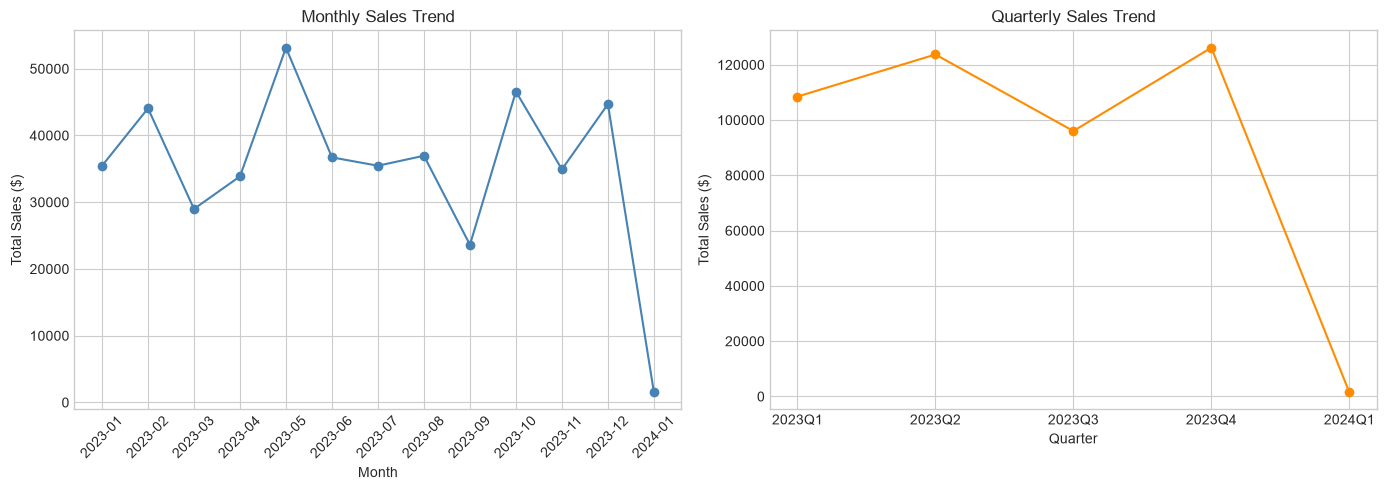

In [21]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

monthly_sales = df.groupby('Month')['Total Amount'].sum()
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o', color='steelblue')
axes[0].set_title('Monthly Sales Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(quarterly_sales.index.astype(str), quarterly_sales.values, marker='o', color='darkorange')
axes[1].set_title('Quarterly Sales Trend')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Total Sales ($)')

plt.tight_layout()
plt.show()

In [ ]:
## Customer Demographics

Understanding who is buying — by age and gender — helps identify which customer segments to prioritize in marketing and product decisions. 
The age column is bucketed into ranges to make the distribution easier to read.

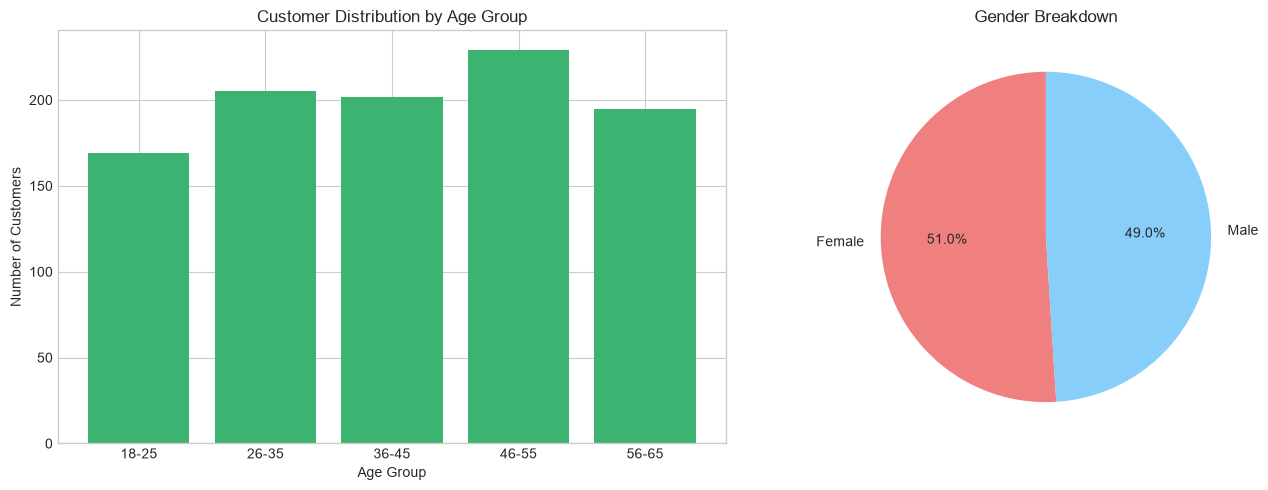

In [22]:
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_group_counts = df['Age Group'].value_counts().sort_index()
axes[0].bar(age_group_counts.index.astype(str), age_group_counts.values, color='mediumseagreen')
axes[0].set_title('Customer Distribution by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Customers')

gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['lightcoral', 'lightskyblue'], startangle=90)
axes[1].set_title('Gender Breakdown')

plt.tight_layout()
plt.show()

In [ ]:
## Product Analysis
This section looks at which products are driving sales volume versus which are driving revenue — the two don't always line up.
Note: this dataset tracks sales at the product *category* level (Beauty, Clothing, Electronics) rather than individual product names,
so the "best-selling products" view below is ranked by category.

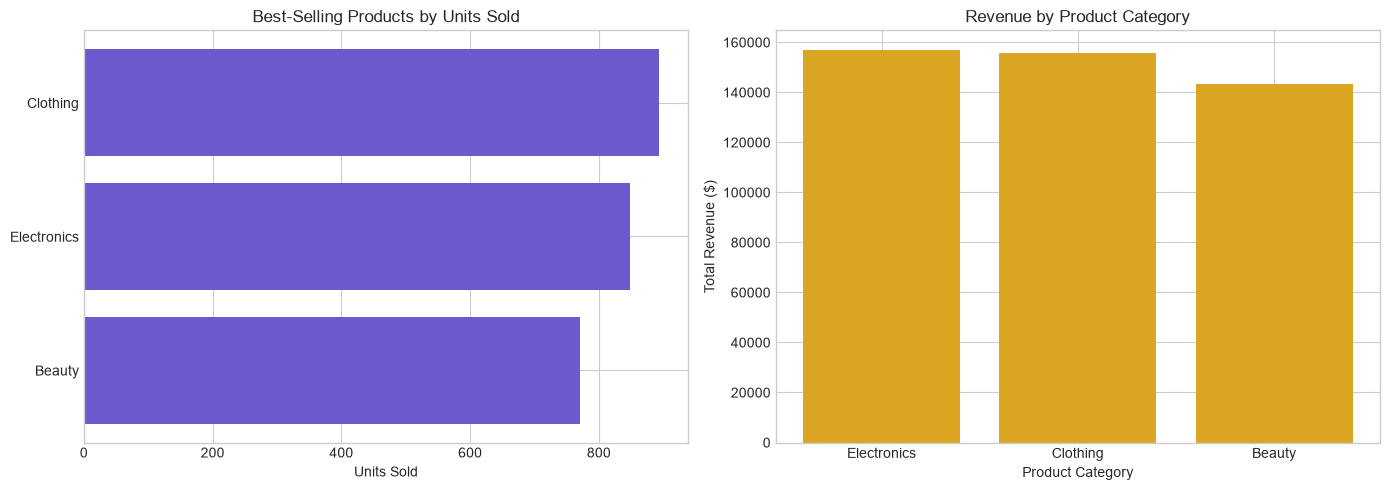

In [23]:
# This dataset records sales at the Product Category level rather than individual
# product names, so "best-selling products" below ranks categories by units sold.
# If your CSV has a separate product name column, swap 'Product Category' for it
# to get item-level rankings instead.
top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False).head(10)
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_products.index, top_products.values, color='slateblue')
axes[0].set_title('Best-Selling Products by Units Sold')
axes[0].set_xlabel('Units Sold')
axes[0].invert_yaxis()

axes[1].bar(category_revenue.index, category_revenue.values, color='goldenrod')
axes[1].set_title('Revenue by Product Category')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

In [ ]:
## Correlation Analysis

A correlation heatmap shows how strongly the numerical variables move together.
For a retail dataset like this, it's a quick way to confirm expected relationships (e.g., between quantity, price, and total amount)
and check whether age has any measurable relationship with spending.

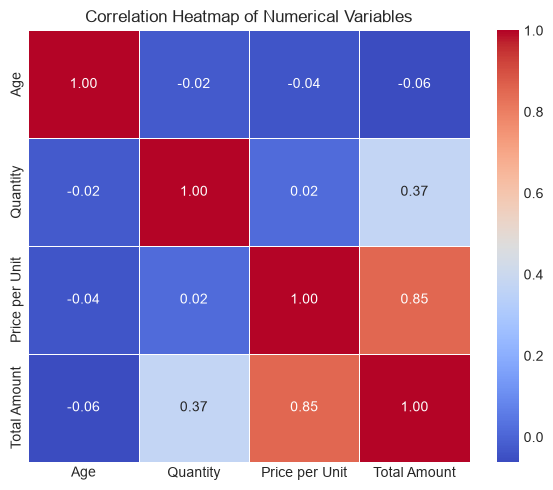

In [24]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

In [ ]:
## Advanced Insight: Spending Patterns Across Age and Category

The demographic and product breakdowns above look at age and category separately — but the more useful business question is how they interact. 
Do older customers spend more on Electronics? Are younger customers driving Beauty sales? 
Cross-referencing average spend by age group and product category surfaces segment-level patterns that a single-variable view would miss,
and points toward where targeted marketing might actually pay off.

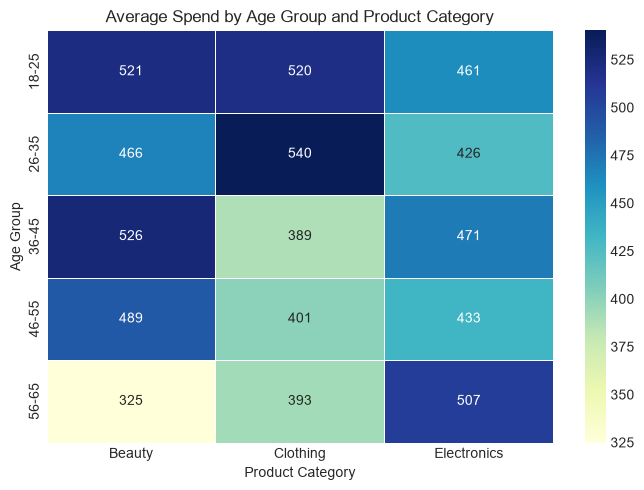

In [25]:
pivot_spend = df.pivot_table(values='Total Amount', index='Age Group',
                              columns='Product Category', aggfunc='mean', observed=False)

plt.figure(figsize=(7, 5))
sns.heatmap(pivot_spend, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Average Spend by Age Group and Product Category')
plt.xlabel('Product Category')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

In [ ]:
## Conclusion & Key Takeaways

* Sales Trend: Monthly sales show fluctuations throughout the year without a strong linear trend, while quarterly sales remain relatively stable, indicating steady overall demand across seasons.
* Customer Profile: The customer base is almost evenly split between males and females, with the 46–55 and 56–65 age groups showing higher engagement in specific categories.
* Product Performance: All three categories (Electronics, Clothing, Beauty) show competitive unit sales, but Electronics generates high overall revenue due to higher price per unit.
* Correlations: Total Amount shows a strong correlation with Price per Unit and Quantity, whereas Customer Age has virtually no linear correlation with spending.
* Segment Insight (Non-obvious):** Customers in the **56–65 age group** spending on **Electronics** recorded the highest average spend (~$507), making them the most profitable micro-segment for targeted marketing.